<a href="https://colab.research.google.com/github/ana-clara-souza/machine-learning/blob/main/PI_0908_Airline_Passenger_Satisfaction_atividade_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer #substitui um dados por outra informação de forma simples, encontra valores faltantes e substitui pela média
from sklearn.preprocessing import StandardScaler #ajusta cada amostra com base na média e desvio padrão -> tende a distribuição Gauciana _> Z SCORE, por deafult
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

#### Leitura da base de dados
* Dataframe Treino
* DataFrame Teste

In [ ]:
treino = pd.read_csv('train.csv.zip', compression = 'zip')
teste = pd.read_csv('test.csv.zip', compression = 'zip')

In [ ]:
treino.shape, teste.shape

((103904, 25), (25976, 25))

#### Exploração da base

In [ ]:
treino['satisfaction'].unique()

array(['neutral or dissatisfied', 'satisfied'], dtype=object)

In [ ]:
treino['satisfaction'].value_counts()

,count
satisfaction,
neutral or dissatisfied,58879
satisfied,45025


<Axes: xlabel='satisfaction', ylabel='count'>

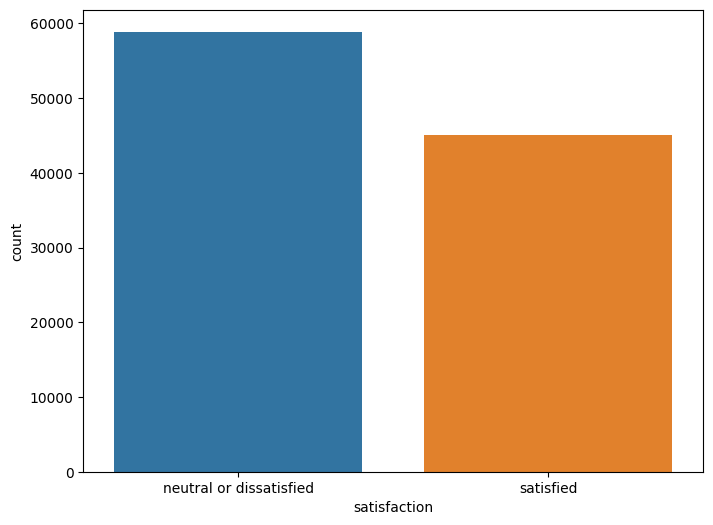

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.countplot(treino, x='satisfaction', hue='satisfaction')

In [ ]:
#dados ausentes

treino.isna().sum()

,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


In [ ]:
teste.isna().sum()

,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


#### Tratamento dos Dados

In [ ]:
# Separar os dados entre as features (preditoras) e a classe/alvo (satisfaction)
# Conhecido como x e y (Matriz colunas e linhas)

In [ ]:
treino.columns

Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [ ]:
# Ajustando os dados de Treino
X_treino = treino.drop(columns=['Unnamed: 0', 'id','satisfaction'], axis=1)
y_treino = treino['satisfaction']

In [ ]:
X_treino.shape, y_treino.shape #prova -> gabarito

((103904, 22), (103904,))

In [ ]:
y_treino

,satisfaction
0,neutral or dissatisfied
1,neutral or dissatisfied
2,satisfied
3,neutral or dissatisfied
4,satisfied
...,...
103899,neutral or dissatisfied
103900,satisfied
103901,neutral or dissatisfied
103902,neutral or dissatisfied


In [ ]:
# Ajustando os dados de Teste
X_teste = teste.drop(columns=['Unnamed: 0', 'id','satisfaction'], axis=1)
y_teste = teste['satisfaction']

In [ ]:
X_teste.shape, y_teste.shape

((25976, 22), (25976,))

#### Transformações
* Normalização dos dados
* Transformação de string para númerico

In [ ]:
treino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [ ]:
# Separar os dados categóricos e numéricos
cat_cols = X_treino.select_dtypes(include='object').columns.tolist()
num_cols = X_treino.select_dtypes(include='number').columns.tolist()

In [ ]:
num_cols

['Age',
 'Flight Distance',
 'Inflight wifi service',
 'Departure/Arrival time convenient',
 'Ease of Online booking',
 'Gate location',
 'Food and drink',
 'Online boarding',
 'Seat comfort',
 'Inflight entertainment',
 'On-board service',
 'Leg room service',
 'Baggage handling',
 'Checkin service',
 'Inflight service',
 'Cleanliness',
 'Departure Delay in Minutes',
 'Arrival Delay in Minutes']

#### Padronização (REESCALA)

In [ ]:
X_treino['Arrival Delay in Minutes'].isna().sum()

np.int64(310)

In [ ]:
# Substituição dos dados faltantes (Treino)

#imputer_numerico = SimpleImputer(strategy='median') #por padrão substitui pela média, se quiser trocar é só especificar
#se tiver muito outlier influencia muito na média

imputer_numerico = SimpleImputer()

X_treino[num_cols] = imputer_numerico.fit_transform(X_treino[num_cols]) #fit -> entenda o padrão, calcule a média e devolve X_treino substituido

#treinado para encontrar todas as  colunas númericas e calcular a média

In [ ]:
X_treino['Arrival Delay in Minutes'].isna().sum()

np.int64(0)

In [ ]:
# Substituição dos dados faltantes (Teste)

X_teste[num_cols] = imputer_numerico.transform(X_teste[num_cols]) #fit -> entenda o padrão, calcule a média e devolve X_treino substituido

#não treinar teste, só transformar usando padrão do conjunto de treino, para não ocorrer vazamento de dados

#Data Leakage (Vazamento)

In [ ]:
X_teste['Arrival Delay in Minutes'].isna().sum()

np.int64(0)

#### Três etapas
* pré processamento (substituição de dado faltantes, normalização, tratamento)
* separação de dados teste e treinamento (fit e predict)

*Pipeline -> Faz automático, ajuda a organizar as colunas

#### Padronização : StandardScaler

In [ ]:
scaler = StandardScaler()
X_treino_padronizado = X_treino.copy()
X_teste_padronizado = X_teste.copy()
X_treino_padronizado[num_cols] = scaler.fit_transform(X_treino[num_cols])
X_teste_padronizado[num_cols] = scaler.transform(X_teste[num_cols])

#Importância de reescalar
#retirar viés de interpretação errada

In [ ]:
X_teste_padronizado.head(2)

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,Female,Loyal Customer,0.834958,Business travel,Eco,-1.032398,1.709804,0.616172,0.173776,0.800803,...,-0.333108,1.231704,1.255590,1.25338,1.158582,-1.030742,1.156436,1.30587,0.920317,0.745879
1,Female,Loyal Customer,-0.223601,Business travel,Business,1.678348,-1.302646,-1.350954,0.173776,-1.547323,...,1.183099,0.481508,0.479403,0.49327,0.311769,-0.240472,0.305848,1.30587,-0.387532,-0.392816


#### Transformação de dados categóricos

In [ ]:
for name in cat_cols:
  print(f"{name}: {X_treino[name].unique()}")

Gender: ['Male' 'Female']
Customer Type: ['Loyal Customer' 'disloyal Customer']
Type of Travel: ['Personal Travel' 'Business travel']
Class: ['Eco Plus' 'Business' 'Eco']


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [ ]:
# Aprender as categorias e os tipos de transformação

encoder.fit(X_treino[cat_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [ ]:
# Codifica as colunas categoricas em Treino e teste
treino_categorico = encoder.transform(X_treino_padronizado[cat_cols]) #gera arrays ai precisa juntar com df para gerar o df ajustado
teste_categorico = encoder.transform(X_teste_padronizado[cat_cols])

In [ ]:
novas_colunas = encoder.get_feature_names_out(cat_cols)

In [ ]:
#Organizar o DataFrame
treino_categorico = pd.DataFrame(treino_categorico, columns = novas_colunas,
                                 index= X_treino_padronizado.index)

teste_categorico = pd.DataFrame(teste_categorico, columns = novas_colunas,
                                 index= X_teste_padronizado.index)

In [ ]:
treino_categorico

,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
103899,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
103900,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
103901,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
103902,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
#Concatenar o novo DataFrame com os Dataframes X_treino e X_teste padronizado,
# não esquecendo de remover as colunas categoricas antigas

In [ ]:
treino_categorico.columns.tolist()

['Gender_Female',
 'Gender_Male',
 'Customer Type_Loyal Customer',
 'Customer Type_disloyal Customer',
 'Type of Travel_Business travel',
 'Type of Travel_Personal Travel',
 'Class_Business',
 'Class_Eco',
 'Class_Eco Plus']

In [ ]:
X_treino_padronizado[cat_cols].columns.tolist()

['Gender', 'Customer Type', 'Type of Travel', 'Class']

In [ ]:
#X_treino_padronizado.drop(columns = cat_cols, axis =1 ) #remove categoricos

#concatenar
X_treino_processado  = pd.concat([X_treino_padronizado.drop(columns = cat_cols),
                                                           treino_categorico],axis=1)

In [ ]:

#concatenar
X_teste_processado  = pd.concat([X_teste_padronizado.drop(columns = cat_cols),
                                                           teste_categorico],axis=1)

In [ ]:
#classe precisa transformar para numero

y_treino.unique()

array(['neutral or dissatisfied', 'satisfied'], dtype=object)

In [ ]:
y_treino = y_treino.map({
    'neutral or dissatisfied' :0,
    'satisfied': 1}
)

In [ ]:
y_teste = y_teste.map({
    'neutral or dissatisfied' :0,
    'satisfied': 1}
)

#### Transformar categorias de satisfaction em 0 e 1

In [ ]:
y_teste

,satisfaction
0,1
1,1
2,0
3,1
4,1
...,...
25971,0
25972,1
25973,0
25974,1


Avaliar com KNN

In [ ]:
#monta-se um grupo e ve por majoritario e classifica

clf = KNeighborsClassifier(n_neighbors=9)

In [ ]:
clf.fit(X_treino_processado, y_treino)

KNeighborsClassifier(n_neighbors=9)

In [ ]:
y_previsto = clf.predict(X_teste_processado)

Avaliação dos acertos

In [ ]:
print(f'Porcentagem de acertos: {accuracy_score(y_teste, y_previsto)*100:.2f}%')

Porcentagem de acertos: 93.14%


### Atividade Prática 1
* i) Rodar o KNN sem a padronização StandardScaler. Verificar se o resultado gerado foi pior;
* ii) Testar (padronizado) o KNN para 7 e 9 vizinhos;
* iii) Comparar os resultados do KNN com o algoritmo de Árvore de Decisão --> sklearn.tree.DecisionTreeClassifier

i)) Print teste comentando StanderScaler

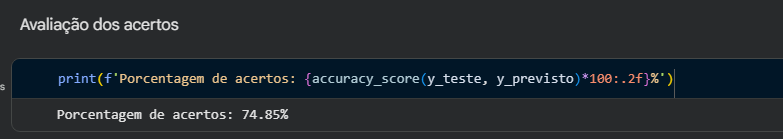

Resposta: A porcentagem de acertos diminuiu de  92.94% para 74.85%, sendo pior o resultado

ii)
#####7 vizinhos -> A porcentagem, de acertos aumentou para 93.02%
#####9 vizinhos -> A poprcentagem de acertos aumentou para 93.14%

iii) Os resultados do KNN foram superiores ao da Árvore de decisão, sendo KNN acima de 90% e da Árvore de decisão 88%

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
#clf.fit(X_treino_processado, y_treino)

#X_treino_processado, X_teste_processado, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=3, random_state=42)

model.fit(X_treino_processado, y_treino)

predictions = model.predict(X_teste_processado)

accuracy = accuracy_score(y_teste, predictions)

print(f'Porcentagem de acertos (Árvore de decisão):{accuracy*100:.2f}%')

Porcentagem de acertos (Árvore de decisão):88.39%
